In [81]:
#not necessary but move down later after loading from drive in new iteration

from google.colab import files
uploaded = files.upload()

Saving SCDB_2025_01_justiceCentered_Citation.csv to SCDB_2025_01_justiceCentered_Citation.csv
Saving SCDB_2025_01_caseCentered_Citation.csv to SCDB_2025_01_caseCentered_Citation.csv


In [82]:
# Data Loading -- Cell 1

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1) constants

CURRENT_JUSTICES = [
    'JGRoberts', 'CThomas', 'SAAlito', 'SSotomayor',
    'EKagan', 'NMGorsuch', 'BMKavanaugh', 'ACBarrett', 'KBJackson'
]

JUSTICE_NAMES = {
    'JGRoberts':  'Chief Justice John Roberts',
    'CThomas':    'Justice Clarence Thomas',
    'SAAlito':    'Justice Samuel Alito',
    'SSotomayor': 'Justice Sonia Sotomayor',
    'EKagan':     'Justice Elena Kagan',
    'NMGorsuch':  'Justice Neil Gorsuch',
    'BMKavanaugh':'Justice Brett Kavanaugh',
    'ACBarrett':  'Justice Amy Coney Barrett',
    'KBJackson':  'Justice Ketanji Brown Jackson'
}

ISSUE_AREAS = {
    1: 'Criminal Procedure',
    2: 'Civil Rights',
    3: 'First Amendment',
    4: 'Due Process',
    5: 'Privacy',
    6: 'Attorneys',
    7: 'Unions',
    8: 'Economic Activity',
    9: 'Judicial Power',
    10: 'Federalism',
    11: 'Interstate Relations',
    12: 'Federal Taxation',
    13: 'Miscellaneous',
    14: 'Private Action'
}

# 2) load data

justice_df = pd.read_csv(
    '/content/SCDB_2025_01_justiceCentered_Citation.csv',
    encoding='latin-1', low_memory=False)

case_df = pd.read_csv(
    '/content/SCDB_2025_01_caseCentered_Citation.csv',
    encoding='latin-1', low_memory=False)

print(f"Justice df: {justice_df.shape}")
print(f"Case df: {case_df.shape}")

# 2) filter/clean data

# Filter to current justices
df = justice_df[justice_df['justiceName'].isin(CURRENT_JUSTICES)].copy()

# Keep only clear majority/dissent votes
df = df[df['vote'].isin([1.0, 2.0])].copy()

# Binary label: 1 = majority, 0 = dissent
df['label'] = (df['vote'] == 1.0).astype(int)

# Parse date
df['term'] = df['term'].astype(int)

# Fill missing issue areas
df['issueArea'] = df['issueArea'].fillna(13)  # 13 = Miscellaneous idk

# Decision direction: 1=conservative, 2=liberal, 3=unspecifiable
df['decisionDirection'] = df['decisionDirection'].fillna(3)

# Majority votes margin
df['voteMargin'] = df['majVotes'] - df['minVotes']

print(f"\nAfter filtering: {len(df):,} rows")
print(f"Label distribution:\n{df['label'].value_counts()}")
print(f"Term range: {df['term'].min()} - {df['term'].max()}")

# 3) add misc justice features

# Martin-Quinn ideology scores (manually entered; established values)
# --> Negative = liberal, Positive = conservative

mq_scores = {
    'JGRoberts':   0.71,
    'CThomas':     3.24,
    'SAAlito':     2.54,
    'SSotomayor': -2.89,
    'EKagan':     -2.17,
    'NMGorsuch':   1.99,
    'BMKavanaugh': 0.95,
    'ACBarrett':   1.73,
    'KBJackson':  -3.11
}

appointing_president = {
    'JGRoberts':   1,  # Bush (R)
    'CThomas':     1,  # Bush (R)
    'SAAlito':     1,  # Bush (R)
    'SSotomayor':  0,  # Obama (D)
    'EKagan':      0,  # Obama (D)
    'NMGorsuch':   1,  # Trump (R)
    'BMKavanaugh': 1,  # Trump (R)
    'ACBarrett':   1,  # Trump (R)
    'KBJackson':   0   # Biden (D)
}

religion_encoded = {
    'JGRoberts':   0,  # Catholic
    'CThomas':     0,  # Catholic
    'SAAlito':     0,  # Catholic
    'SSotomayor':  0,  # Catholic
    'EKagan':      1,  # Jewish
    'NMGorsuch':   2,  # Episcopal
    'BMKavanaugh': 0,  # Catholic
    'ACBarrett':   0,  # Catholic
    'KBJackson':   3   # Protestant
}

prior_experience = {
    'JGRoberts':   1,  # Federal appellate judge
    'CThomas':     1,
    'SAAlito':     1,
    'SSotomayor':  1,
    'EKagan':      0,  # No prior judicial experience
    'NMGorsuch':   1,
    'BMKavanaugh': 1,
    'ACBarrett':   1,
    'KBJackson':   1
}

years_on_court = {
    'JGRoberts':   20,
    'CThomas':     33,
    'SAAlito':     19,
    'SSotomayor':  15,
    'EKagan':      14,
    'NMGorsuch':   8,
    'BMKavanaugh': 6,
    'ACBarrett':   4,
    'KBJackson':   2
}

# add justice features to df
df['mq_score']           = df['justiceName'].map(mq_scores)
df['appointing_president']= df['justiceName'].map(appointing_president)
df['religion_encoded']   = df['justiceName'].map(religion_encoded)
df['prior_experience']   = df['justiceName'].map(prior_experience)
df['years_on_court']     = df['justiceName'].map(years_on_court)

# justice index (0-8) for the output heads
df['justice_idx'] = df['justiceName'].apply(
    lambda x: CURRENT_JUSTICES.index(x))

print(f"\nJustice features added")
print(df[['justiceName', 'mq_score', 'appointing_president']].drop_duplicates())

Justice df: (83644, 61)
Case df: (9341, 53)

After filtering: 8,099 rows
Label distribution:
label
1    6563
0    1536
Name: count, dtype: int64
Term range: 1991 - 2024

Justice features added
       justiceName  mq_score  appointing_president
58811      CThomas      3.24                     1
70503    JGRoberts      0.71                     1
70755      SAAlito      2.54                     1
73372   SSotomayor     -2.89                     0
74209       EKagan     -2.17                     0
78803    NMGorsuch      1.99                     1
79692  BMKavanaugh      0.95                     1
80943    ACBarrett      1.73                     1
82032    KBJackson     -3.11                     0


In [83]:
# Fetching text from Oyez API -- Cell 2

import requests
import time
import re
from functools import lru_cache

@lru_cache(maxsize=None)
def fetch_term_cases(term):
    """Fetch all cases for a term from Oyez — cached so only one call/term"""
    try:
        url = f"https://api.oyez.org/cases?per_page=300&filter=term:{int(term)}"
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            return r.json()
    except:
        pass
    return []

def fetch_oyez_summary(case_name, term):
    """Match case name against Oyez cases for given term."""
    cases = fetch_term_cases(term)
    if not cases:
        return None

    # Clean case name for matching
    clean_name = case_name.lower().split('v.')[0].strip()
    clean_name = re.sub(r'[^\w\s]', '', clean_name).strip()

    best_match = None
    best_score = 0

    for case in cases:
        oyez_name = case.get('name', '').lower()
        oyez_clean = re.sub(r'[^\w\s]', '', oyez_name).strip()

        # Simple overlap score
        name_words = set(clean_name.split())
        oyez_words = set(oyez_clean.split())
        overlap = len(name_words & oyez_words)

        if overlap > best_score:
            best_score = overlap
            best_match = case

    if best_match and best_score >= 1:
        desc = best_match.get('description', '') or ''
        question = best_match.get('question', '') or ''
        text = f"{desc} {question}".strip()
        text = re.sub(r'<[^>]+>', '', text).strip()
        if text:
            return text

    return None

# Test, ignore
test_cases = [
    ("Dobbs v. Jackson Women's Health Organization", 2021),
    ("New York State Rifle & Pistol Association v. Bruen", 2021),
    ("Obergefell v. Hodges", 2014),
    ("Bush v. Gore", 2000),
]

for case_name, term in test_cases:
    result = fetch_oyez_summary(case_name, term)
    if result:
        print(f"T {case_name[:45]}: {result[:80]}...")
    else:
        print(f"F {case_name[:45]}: not found")

T Dobbs v. Jackson Women's Health Organization: A case in which the Court overruled Roe v. Wade and Planned Parenthood v. Casey,...
T New York State Rifle & Pistol Association v. : A case in which the Court held that New York's law requiring applications for co...
T Obergefell v. Hodges: A case in which the Court held that the Fourteenth Amendment requires states to ...
T Bush v. Gore: Do post-election court decisions that limit legislators' or executive officials'...


In [84]:
# Fetching Oyez Summary -- Cell 3

def fetch_oyez_summary(case_name, term):
    cases = fetch_term_cases(term)
    if not cases:
        return None

    # Use full case name for matching
    clean_name = re.sub(r'[^\w\s]', '', case_name.lower()).strip()
    name_words = set(clean_name.split()) - {'v', 'vs', 'et', 'al', 'inc',
                                            'llc', 'corp'}

    best_match = None
    best_score = 0

    for case in cases:
        oyez_name = case.get('name', '').lower()
        oyez_clean = re.sub(r'[^\w\s]', '', oyez_name).strip()
        oyez_words = set(oyez_clean.split()) - {'v', 'vs', 'et', 'al', 'inc',
                                                'llc', 'corp'}

        overlap = len(name_words & oyez_words)
        # Bonus for matching both petitioner and respondent
        score = overlap / max(len(name_words), 1)

        if score > best_score:
            best_score = score
            best_match = case

    # Require at least 40% word overlap hmm maybe increase
    if best_match and best_score >= 0.4:
        desc = best_match.get('description', '') or ''
        question = best_match.get('question', '') or ''
        text = f"{desc} {question}".strip()
        text = re.sub(r'<[^>]+>', '', text).strip()
        if text:
            return text

    return None

In [86]:
# Get Unique Case-term Pairs -- Cell 4

# clear cache just in case (for testing purposes)
fetch_term_cases.cache_clear()

unique_cases = df[['caseName', 'term']].drop_duplicates()
print(f"Unique cases to fetch: {len(unique_cases)}")

# Fetch summaries
case_texts = {}
failed = 0

for i, row in unique_cases.iterrows():
    text = fetch_oyez_summary(row['caseName'], row['term'])
    if text:
        case_texts[row['caseName']] = text
    else:
        case_texts[row['caseName']] = row['caseName']  # fallback to name
        failed += 1

    if (len(case_texts)) % 50 == 0:
        print(f"Progress: {len(case_texts)}/{len(unique_cases)} — failed: {failed}")

    time.sleep(0.1)

print(f"\nDone — {len(case_texts) - failed}/{len(unique_cases)} with Oyez text")
print(f"Using name fallback: {failed}")

# Add to df
df['case_text'] = df['caseName'].map(case_texts)
print(f"\nSample:")
print(df['case_text'].iloc[0][:200])

Unique cases to fetch: 2561
Progress: 50/2561 — failed: 41
Progress: 100/2561 — failed: 78
Progress: 150/2561 — failed: 124
Progress: 200/2561 — failed: 165
Progress: 250/2561 — failed: 201
Progress: 300/2561 — failed: 235
Progress: 350/2561 — failed: 268
Progress: 400/2561 — failed: 297
Progress: 450/2561 — failed: 315
Progress: 500/2561 — failed: 339
Progress: 550/2561 — failed: 358
Progress: 600/2561 — failed: 368
Progress: 650/2561 — failed: 380
Progress: 700/2561 — failed: 398
Progress: 750/2561 — failed: 413
Progress: 800/2561 — failed: 424
Progress: 850/2561 — failed: 435
Progress: 900/2561 — failed: 452
Progress: 950/2561 — failed: 466
Progress: 1000/2561 — failed: 484
Progress: 1050/2561 — failed: 499
Progress: 1100/2561 — failed: 520
Progress: 1150/2561 — failed: 537
Progress: 1200/2561 — failed: 553
Progress: 1250/2561 — failed: 567
Progress: 1300/2561 — failed: 576
Progress: 1350/2561 — failed: 584
Progress: 1400/2561 — failed: 596
Progress: 1450/2561 — failed: 619
Progress

In [87]:
# Embed Case Texts & Implement PCA Reduction -- Cell 5

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import numpy as np

embed_model = SentenceTransformer('all-mpnet-base-v2')

# 1) Get unique case texts
unique_case_texts = df[['caseName', 'case_text']].drop_duplicates('caseName')
texts = unique_case_texts['case_text'].tolist()
case_names = unique_case_texts['caseName'].tolist()

case_embeddings = embed_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"Raw embeddings: {case_embeddings.shape}") #testing

# 2) PCA reduce
pca = PCA(n_components=64, random_state=42)
case_embeddings_reduced = pca.fit_transform(case_embeddings)
explained = pca.explained_variance_ratio_.sum()
print(f"PCA: 768d → 64d, variance explained: {explained:.1%}")

# Map back to df
case_emb_map = {name: i for i, name in enumerate(case_names)}
df['emb_idx'] = df['caseName'].map(case_emb_map)

print(f"Missing embeddings: {df['emb_idx'].isna().sum()}") #testing

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Raw embeddings: (2536, 768)
PCA: 768d → 64d, variance explained: 65.2%
Missing embeddings: 0


In [88]:
# Download to Drive -- Cell 6

from google.colab import drive
drive.mount('/content/drive')
import os, pickle, joblib

BASE = '/content/drive/MyDrive/scotus_project'
os.makedirs(BASE, exist_ok=True)

np.save(f'{BASE}/case_embeddings.npy', case_embeddings_reduced)
joblib.dump(pca, f'{BASE}/pca.pkl')
joblib.dump(embed_model, f'{BASE}/embed_model.pkl')

# Save case name to embedding index map
with open(f'{BASE}/case_emb_map.pkl', 'wb') as f:
    pickle.dump(case_emb_map, f)

# Save main dataframe
df.to_parquet(f'{BASE}/scotus_df.parquet')

print("Saved")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved


In [89]:
# Load From Drive -- Cell 7

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.decomposition import PCA
import joblib
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/scotus_project'

# 1) Load saved data
df = pd.read_parquet(f'{BASE}/scotus_df.parquet')
case_embeddings_reduced = np.load(f'{BASE}/case_embeddings.npy')
pca = joblib.load(f'{BASE}/pca.pkl')

with open(f'{BASE}/case_emb_map.pkl', 'rb') as f:
    case_emb_map = pickle.load(f)

print(f"df: {df.shape}")
print(f"case_embeddings: {case_embeddings_reduced.shape}")

# 2) Rebuild constants
CURRENT_JUSTICES = [
    'JGRoberts', 'CThomas', 'SAAlito', 'SSotomayor',
    'EKagan', 'NMGorsuch', 'BMKavanaugh', 'ACBarrett', 'KBJackson'
]

JUSTICE_NAMES = {
    'JGRoberts':  'Chief Justice John Roberts',
    'CThomas':    'Justice Clarence Thomas',
    'SAAlito':    'Justice Samuel Alito',
    'SSotomayor': 'Justice Sonia Sotomayor',
    'EKagan':     'Justice Elena Kagan',
    'NMGorsuch':  'Justice Neil Gorsuch',
    'BMKavanaugh':'Justice Brett Kavanaugh',
    'ACBarrett':  'Justice Amy Coney Barrett',
    'KBJackson':  'Justice Ketanji Brown Jackson'
}

# 3) Rebuild df_clean ugh
df_clean = df[df['vote'].isin([1.0, 2.0])].copy()
df_clean = df_clean.dropna(subset=['mq_score', 'emb_idx']).copy()
df_clean['emb_idx'] = df_clean['emb_idx'].astype(int)
df_clean['justice_idx'] = df_clean['justiceName'].apply(
    lambda x: CURRENT_JUSTICES.index(x))

print(f"df_clean: {len(df_clean):,} rows") #testing, just to double check

print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
df: (8099, 71)
case_embeddings: (2536, 64)
df_clean: 8,099 rows
Device: cuda


In [90]:
# Add Historical Majority Rate + Bias -- Cell 8

# Compute directly NO merge
df_clean = df_clean.drop(columns=[c for c in df_clean.columns
                                    if 'majority_rate' in c], errors='ignore')

# Direct assignment
df_clean['historical_majority_rate'] = df_clean.groupby(
    'justiceName')['label'].transform('mean')

df_clean['issue_majority_rate'] = df_clean.groupby(
    ['justiceName', 'issueArea'])['label'].transform('mean')

df_clean['issue_majority_rate'] = df_clean['issue_majority_rate'].fillna(
    df_clean['historical_majority_rate'])

print("Historical majority rates:")
print(df_clean[['justiceName', 'historical_majority_rate',
                'issue_majority_rate']].drop_duplicates('justiceName'))

# Per-justice per-issue bias vs court average
court_rate_by_issue = df_clean.groupby('issueArea')['label'].transform('mean')
df_clean['justice_issue_bias'] = df_clean['issue_majority_rate'] - court_rate_by_issue

print("\nJustice issue bias (sorted):")
print(df_clean.groupby('justiceName')['justice_issue_bias'].mean().sort_values())


Historical majority rates:
       justiceName  historical_majority_rate  issue_majority_rate
58811      CThomas                  0.765039             0.873900
70503    JGRoberts                  0.902878             0.865385
70755      SAAlito                  0.799187             0.867647
73372   SSotomayor                  0.755203             0.792000
74209       EKagan                  0.814776             0.807531
78803    NMGorsuch                  0.776744             0.745763
79692  BMKavanaugh                  0.928947             0.866667
80943    ACBarrett                  0.901515             1.000000
82032    KBJackson                  0.709220             1.000000

Justice issue bias (sorted):
justiceName
KBJackson     -0.107081
SSotomayor    -0.053437
CThomas       -0.044560
NMGorsuch     -0.037473
SAAlito       -0.011706
EKagan         0.004601
ACBarrett      0.089461
JGRoberts      0.093108
BMKavanaugh    0.116554
Name: justice_issue_bias, dtype: float64


In [91]:
# Add Feature Cols & Direction Features -- Cell 9

# 1) establish feature cols

JUSTICE_FEATURE_COLS = [
    'mq_score',
    'appointing_president',
    'religion_encoded',
    'prior_experience',
    'years_on_court',
    'historical_majority_rate',
    'issue_majority_rate',
    'justice_issue_bias',
]

# 2) add direction features to df_clean

df_clean['direction_conservative'] = (df_clean['decisionDirection'] == 1.0).astype(float)
df_clean['direction_liberal']      = (df_clean['decisionDirection'] == 2.0).astype(float)
df_clean['vote_margin_normalized'] = df_clean['voteMargin'] / 9.0

print(f"JUSTICE_FEATURE_COLS: {JUSTICE_FEATURE_COLS}")

JUSTICE_FEATURE_COLS: ['mq_score', 'appointing_president', 'religion_encoded', 'prior_experience', 'years_on_court', 'historical_majority_rate', 'issue_majority_rate', 'justice_issue_bias']


In [92]:
# K-Fold Cross Validation -- Cell 10

from sklearn.model_selection import StratifiedKFold
import numpy as np

# 1) Stratify by justice so each fold has all justices
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2) se justice_idx as the stratification target
folds = list(skf.split(df_clean, df_clean['justice_idx']))

train_idx = np.concatenate([folds[0][0], folds[1][0], folds[2][0]])
val_idx   = folds[3][1]
test_idx  = folds[4][1]

train_df = df_clean.iloc[train_idx].copy()
val_df   = df_clean.iloc[val_idx].copy()
test_df  = df_clean.iloc[test_idx].copy()

print(f"Train: {len(train_df):,}, Val: {len(val_df):,}, Test: {len(test_df):,}")
print("\nJustices in test:")
print(test_df['justiceName'].value_counts())
print(val_df['justiceName'].value_counts())

Train: 19,437, Val: 1,620, Test: 1,619

Justices in test:
justiceName
CThomas        458
JGRoberts      278
SAAlito        246
SSotomayor     202
EKagan         192
NMGorsuch       86
BMKavanaugh     76
ACBarrett       53
KBJackson       28
Name: count, dtype: int64
justiceName
CThomas        459
JGRoberts      278
SAAlito        246
SSotomayor     201
EKagan         193
NMGorsuch       86
BMKavanaugh     76
ACBarrett       52
KBJackson       29
Name: count, dtype: int64


In [93]:
# Feature Matrix Cell -- Cell 11

# 1) Scale justice features
justice_scaler = StandardScaler()
X_justice_train = justice_scaler.fit_transform(train_df[JUSTICE_FEATURE_COLS])
X_justice_val   = justice_scaler.transform(val_df[JUSTICE_FEATURE_COLS])
X_justice_test  = justice_scaler.transform(test_df[JUSTICE_FEATURE_COLS])

# 2) Case embeddings + direction features
case_extra_cols = ['direction_conservative', 'direction_liberal',
                   'vote_margin_normalized']

train_extra = train_df[case_extra_cols].fillna(0).values
val_extra   = val_df[case_extra_cols].fillna(0).values
test_extra  = test_df[case_extra_cols].fillna(0).values

X_case_train = np.hstack([case_embeddings_reduced[train_df['emb_idx'].values], train_extra])
X_case_val   = np.hstack([case_embeddings_reduced[val_df['emb_idx'].values],   val_extra])
X_case_test  = np.hstack([case_embeddings_reduced[test_df['emb_idx'].values],  test_extra])

justice_idx_train = train_df['justice_idx'].values
justice_idx_val   = val_df['justice_idx'].values
justice_idx_test  = test_df['justice_idx'].values

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

print(f"Justice features: {X_justice_train.shape}")
print(f"Case features:    {X_case_train.shape}")  # dc that it is (n, 67)

Justice features: (19437, 8)
Case features:    (19437, 67)


In [94]:
# Define Models -- Cell 12

class SCOTUSDataset(torch.utils.data.Dataset):
    def __init__(self, justice_features, case_features,
                 justice_indices, labels):
        self.justice_features = torch.FloatTensor(justice_features)
        self.case_features    = torch.FloatTensor(case_features)
        self.justice_indices  = torch.LongTensor(justice_indices)
        self.labels           = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (self.justice_features[idx],
                self.case_features[idx],
                self.justice_indices[idx],
                self.labels[idx])


class SCOTUSModel(nn.Module):
    def __init__(self, justice_input_dim, case_input_dim,
                 n_justices=9, embedding_dim=64):
        super().__init__()

        self.case_branch = nn.Sequential(
            nn.Linear(case_input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, embedding_dim),
            nn.ReLU()
        )

        self.justice_branch = nn.Sequential(
            nn.Linear(justice_input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, embedding_dim),
            nn.ReLU()
        )

        self.shared = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Linear(32, 1),
                nn.Sigmoid()
            ) for _ in range(n_justices)
        ])

    #forward prop
    def forward(self, justice_features, case_features, justice_indices):
        case_emb    = self.case_branch(case_features)
        justice_emb = self.justice_branch(justice_features)
        combined    = torch.cat([case_emb, justice_emb], dim=1)
        shared_repr = self.shared(combined)

        outputs = torch.zeros(len(justice_indices), device=shared_repr.device)
        for j in range(9):
            mask = (justice_indices == j)
            if mask.sum() > 0:
                outputs[mask] = self.heads[j](shared_repr[mask]).squeeze(1)

        return outputs

Device: cuda
Case features: (19437, 67)
Parameters: 63,721
Epoch 01/30 | Loss: 0.2414 | F1: 0.7446 | AUC: 0.9119 | Acc: 0.7969
  ✓ Best model saved (F1=0.7446)
Epoch 02/30 | Loss: 0.2143 | F1: 0.7650 | AUC: 0.9357 | Acc: 0.8099
  ✓ Best model saved (F1=0.7650)
Epoch 03/30 | Loss: 0.2107 | F1: 0.7991 | AUC: 0.9344 | Acc: 0.8451
  ✓ Best model saved (F1=0.7991)
Epoch 04/30 | Loss: 0.2091 | F1: 0.8109 | AUC: 0.9429 | Acc: 0.8543
  ✓ Best model saved (F1=0.8109)
Epoch 05/30 | Loss: 0.2076 | F1: 0.8215 | AUC: 0.9459 | Acc: 0.8642
  ✓ Best model saved (F1=0.8215)
Epoch 06/30 | Loss: 0.2062 | F1: 0.8272 | AUC: 0.9476 | Acc: 0.8691
  ✓ Best model saved (F1=0.8272)
Epoch 07/30 | Loss: 0.2053 | F1: 0.8347 | AUC: 0.9478 | Acc: 0.8759
  ✓ Best model saved (F1=0.8347)
Epoch 08/30 | Loss: 0.2048 | F1: 0.8333 | AUC: 0.9489 | Acc: 0.8747
Epoch 09/30 | Loss: 0.2049 | F1: 0.8351 | AUC: 0.9485 | Acc: 0.8765
  ✓ Best model saved (F1=0.8351)
Epoch 10/30 | Loss: 0.2041 | F1: 0.8437 | AUC: 0.9501 | Acc: 0.88

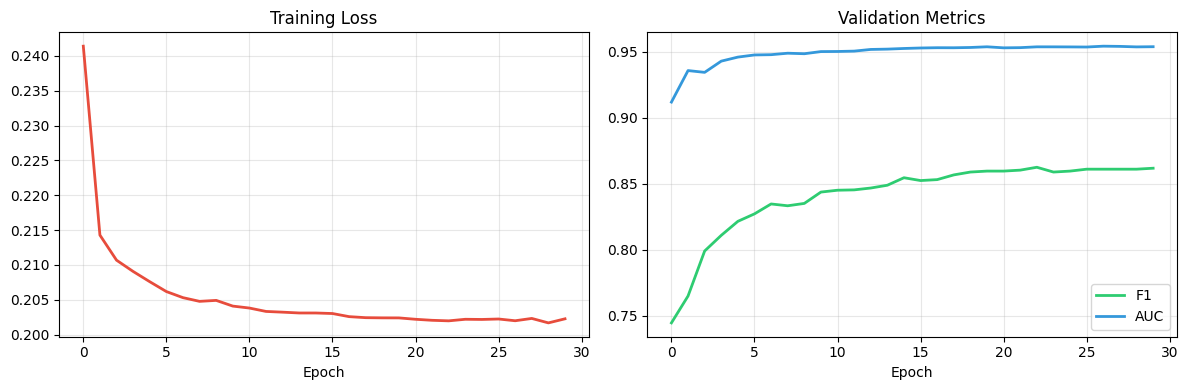


FINAL TEST RESULTS
Accuracy: 0.9185
F1 Macro: 0.8802
ROC AUC:  0.9665

Per-justice accuracy:
  Chief Justice John Roberts              : acc=0.924 (278 cases)
  Justice Clarence Thomas                 : acc=0.930 (458 cases)
  Justice Samuel Alito                    : acc=0.915 (246 cases)
  Justice Sonia Sotomayor                 : acc=0.941 (202 cases)
  Justice Elena Kagan                     : acc=0.938 (192 cases)
  Justice Neil Gorsuch                    : acc=0.698 (86 cases)
  Justice Brett Kavanaugh                 : acc=0.934 (76 cases)
  Justice Amy Coney Barrett               : acc=0.962 (53 cases)
  Justice Ketanji Brown Jackson           : acc=0.964 (28 cases)


In [95]:
# Training -- Cell 13

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print(f"Case features: {X_case_train.shape}")  # confirm 67

pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()]).to(device)

train_dataset = SCOTUSDataset(X_justice_train, X_case_train,
                               justice_idx_train, y_train)
val_dataset   = SCOTUSDataset(X_justice_val,   X_case_val,
                               justice_idx_val,   y_val)
test_dataset  = SCOTUSDataset(X_justice_test,  X_case_test,
                               justice_idx_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=256,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=256,
                          shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=256,
                          shuffle=False, num_workers=2)

model = SCOTUSModel(
    justice_input_dim=len(JUSTICE_FEATURE_COLS),
    case_input_dim=X_case_train.shape[1],
    n_justices=9,
    embedding_dim=64
)
model = model.to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

best_val_f1 = 0
best_state  = None
train_losses = []
val_metrics  = []

for epoch in range(30): #test diff ranges
    model.train()
    total_loss = 0
    for jf, cf, ji, y in train_loader:
        jf, cf, ji, y = jf.to(device), cf.to(device), ji.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(jf, cf, ji)
        loss  = criterion(preds, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)


    model.eval()
    val_preds, val_labels, val_probas = [], [], []
    with torch.no_grad():
        for jf, cf, ji, y in val_loader:
            jf, cf, ji = jf.to(device), cf.to(device), ji.to(device)
            probas = model(jf, cf, ji).cpu().numpy()
            preds  = (probas > 0.5).astype(int)
            val_preds.extend(preds)
            val_probas.extend(probas)
            val_labels.extend(y.numpy())

    val_f1  = f1_score(val_labels, val_preds, average='macro')
    val_auc = roc_auc_score(val_labels, val_probas)
    val_acc = accuracy_score(val_labels, val_preds)
    val_metrics.append({'f1': val_f1, 'auc': val_auc, 'acc': val_acc})
    scheduler.step(val_f1)

    print(f"Epoch {epoch+1:02d}/30 | Loss: {avg_loss:.4f} | "
          f"F1: {val_f1:.4f} | AUC: {val_auc:.4f} | Acc: {val_acc:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state  = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  ✓ Best model saved (F1={val_f1:.4f})")

model.load_state_dict(best_state)

# Plots for eval
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color='#e74c3c', linewidth=2)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.grid(True, alpha=0.3)
ax2.plot([m['f1'] for m in val_metrics], color='#2ecc71',
         linewidth=2, label='F1')
ax2.plot([m['auc'] for m in val_metrics], color='#3498db',
         linewidth=2, label='AUC')
ax2.set_title('Validation Metrics')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


# Test eval
model.eval()
test_preds, test_labels, test_probas = [], [], []
with torch.no_grad():
    for jf, cf, ji, y in test_loader:
        jf, cf, ji = jf.to(device), cf.to(device), ji.to(device)
        probas = model(jf, cf, ji).cpu().numpy()
        preds  = (probas > 0.5).astype(int)
        test_preds.extend(preds)
        test_probas.extend(probas)
        test_labels.extend(y.numpy())

#print metrics for eval
print("\n" + "="*50)
print("FINAL TEST RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(test_labels, test_preds):.4f}")
print(f"F1 Macro: {f1_score(test_labels, test_preds, average='macro'):.4f}")
print(f"ROC AUC:  {roc_auc_score(test_labels, test_probas):.4f}")

print("\nPer-justice accuracy:")
test_df_copy = test_df.copy().reset_index(drop=True)
test_df_copy['pred'] = test_preds
test_df_copy['proba'] = test_probas
test_df_copy['correct'] = (test_df_copy['pred'] == test_df_copy['label'])

for j in CURRENT_JUSTICES:
    jdf = test_df_copy[test_df_copy['justiceName'] == j]
    if len(jdf) > 0:
        print(f"  {JUSTICE_NAMES[j]:40s}: "
              f"acc={jdf['correct'].mean():.3f} "
              f"({len(jdf)} cases)")

In [96]:
#Save necessary files to drive folder (version 5? rn) -- Cell 14

import torch, joblib, pickle

BASE = '/content/drive/MyDrive/scotus_project'

torch.save(model.state_dict(), f'{BASE}/scotus_model_v5.pt')
joblib.dump(justice_scaler, f'{BASE}/justice_scaler_v5.pkl')

with open(f'{BASE}/justice_feature_cols_v5.pkl', 'wb') as f:
    pickle.dump(JUSTICE_FEATURE_COLS, f)

df_clean.to_parquet(f'{BASE}/scotus_df_clean_v5.parquet')

print("Saved v5")

Saved v5
